In [ ]:
# Install required libraries
!pip install wordcloud scikit-learn pandas numpy matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# Plotting style
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [ ]:
from google.colab import files

print('Please upload your True.csv and Fake.csv files...')
uploaded = files.upload()

Please upload your True.csv and Fake.csv files...


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [ ]:
# Load datasets
true_df  = pd.read_csv('True.csv')
fake_df  = pd.read_csv('Fake.csv')

# Assign labels
true_df['label'] = 1   # 1 = Real News
fake_df['label'] = 0   # 0 = Fake News

# Combine
df = pd.concat([true_df, fake_df], ignore_index=True)

# Ensure 'text' column exists
if 'text' not in df.columns and 'title' in df.columns:
    df['text'] = df['title'].astype(str) + ' ' + df.get('subject', pd.Series([''] * len(df))).astype(str)
elif 'text' not in df.columns:
    # Use first string column available
    str_cols = df.select_dtypes(include='object').columns.tolist()
    df['text'] = df[str_cols[0]]

print(f' Dataset loaded!')
print(f'   Total samples : {len(df):,}')
print(f'   Real News     : {len(true_df):,}')
print(f'   Fake News     : {len(fake_df):,}')
df.head(3)

 Dataset loaded!
   Total samples : 44,898
   Real News     : 21,417
   Fake News     : 23,481


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1


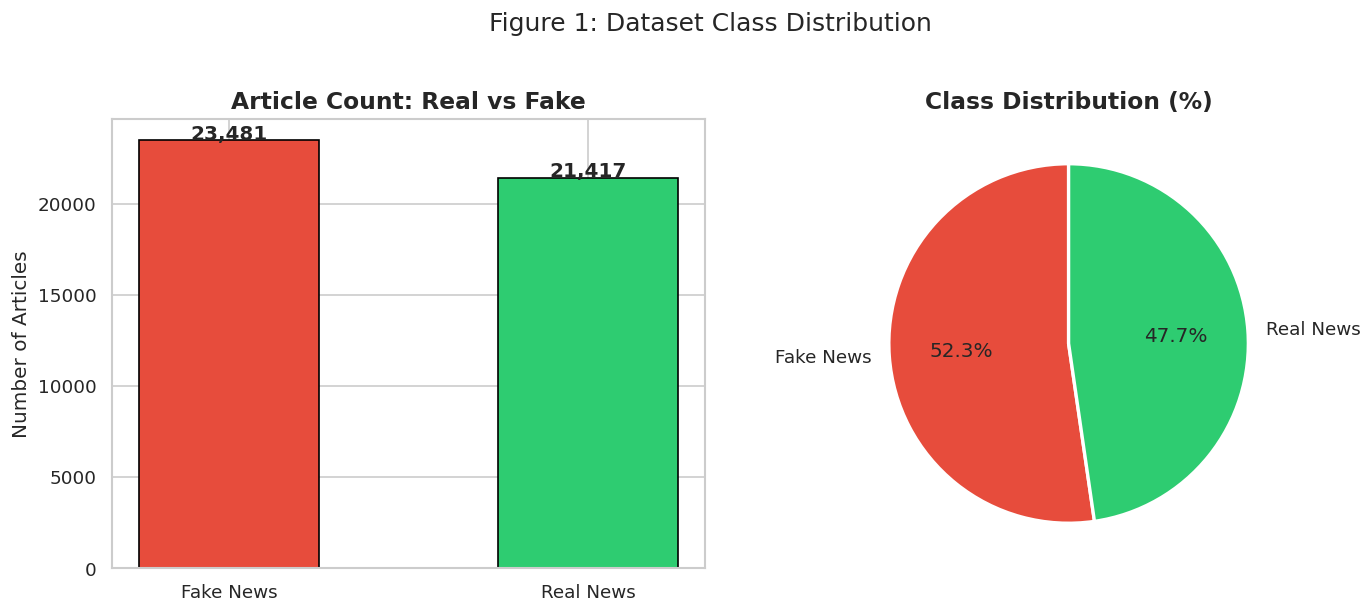

 Figure 1 saved.


In [ ]:
# ── 3.1 Class Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#2ecc71']

# Bar chart
axes[0].bar(['Fake News', 'Real News'], label_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Article Count: Real vs Fake', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=['Fake News', 'Real News'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Figure 1: Dataset Class Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print(' Figure 1 saved.')

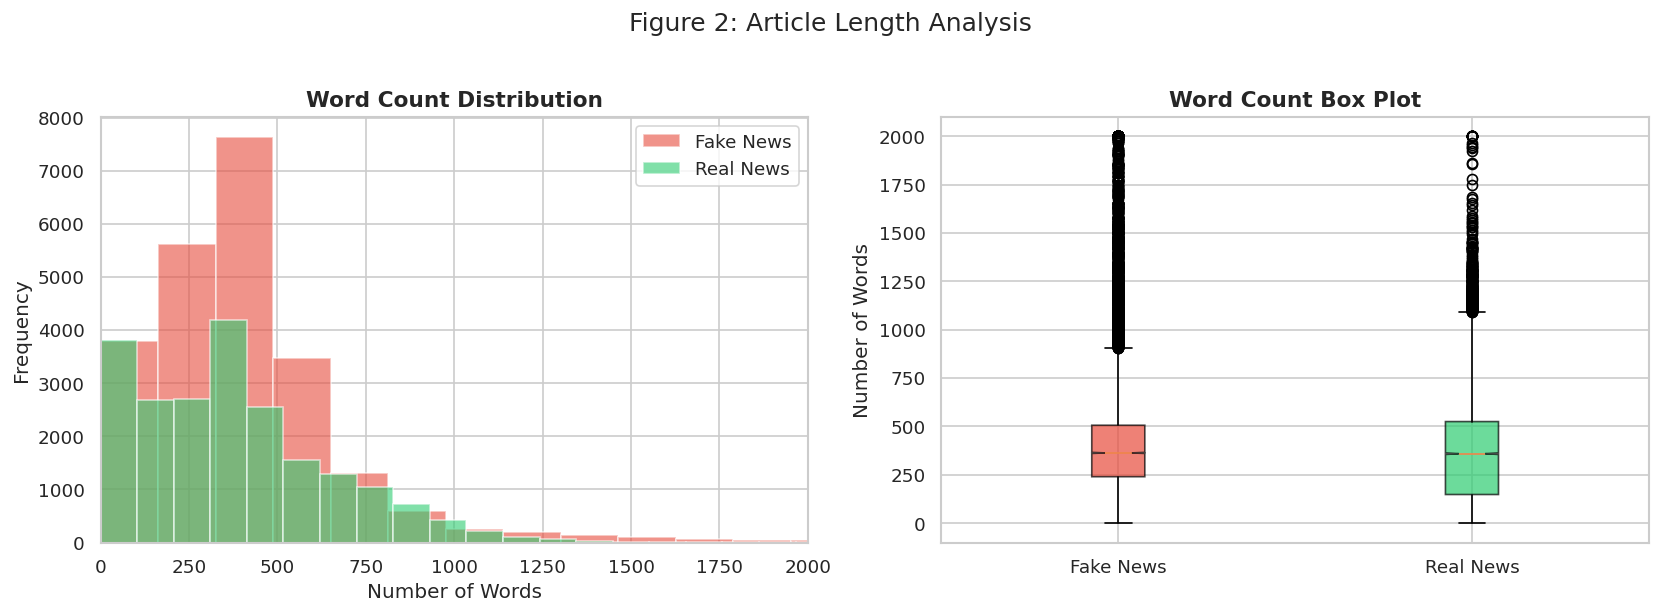

Real News  — Mean words: 386, Median: 359
Fake News  — Mean words: 423, Median: 363
 Figure 2 saved.


In [ ]:
# ── 3.2 Article Length Analysis ────────────────────────────────────────────
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color, name in [(0, '#e74c3c', 'Fake'), (1, '#2ecc71', 'Real')]:
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=f'{name} News')
axes[0].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 2000)

# Box plot
data_to_plot = [df[df['label']==0]['text_length'].clip(0,2000),
                df[df['label']==1]['text_length'].clip(0,2000)]
bp = axes[1].boxplot(data_to_plot, labels=['Fake News', 'Real News'],
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Word Count Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Words')

plt.suptitle('Figure 2: Article Length Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig2_article_length.png', bbox_inches='tight')
plt.show()

print(f"Real News  — Mean words: {df[df['label']==1]['text_length'].mean():.0f}, Median: {df[df['label']==1]['text_length'].median():.0f}")
print(f"Fake News  — Mean words: {df[df['label']==0]['text_length'].mean():.0f}, Median: {df[df['label']==0]['text_length'].median():.0f}")
print(' Figure 2 saved.')

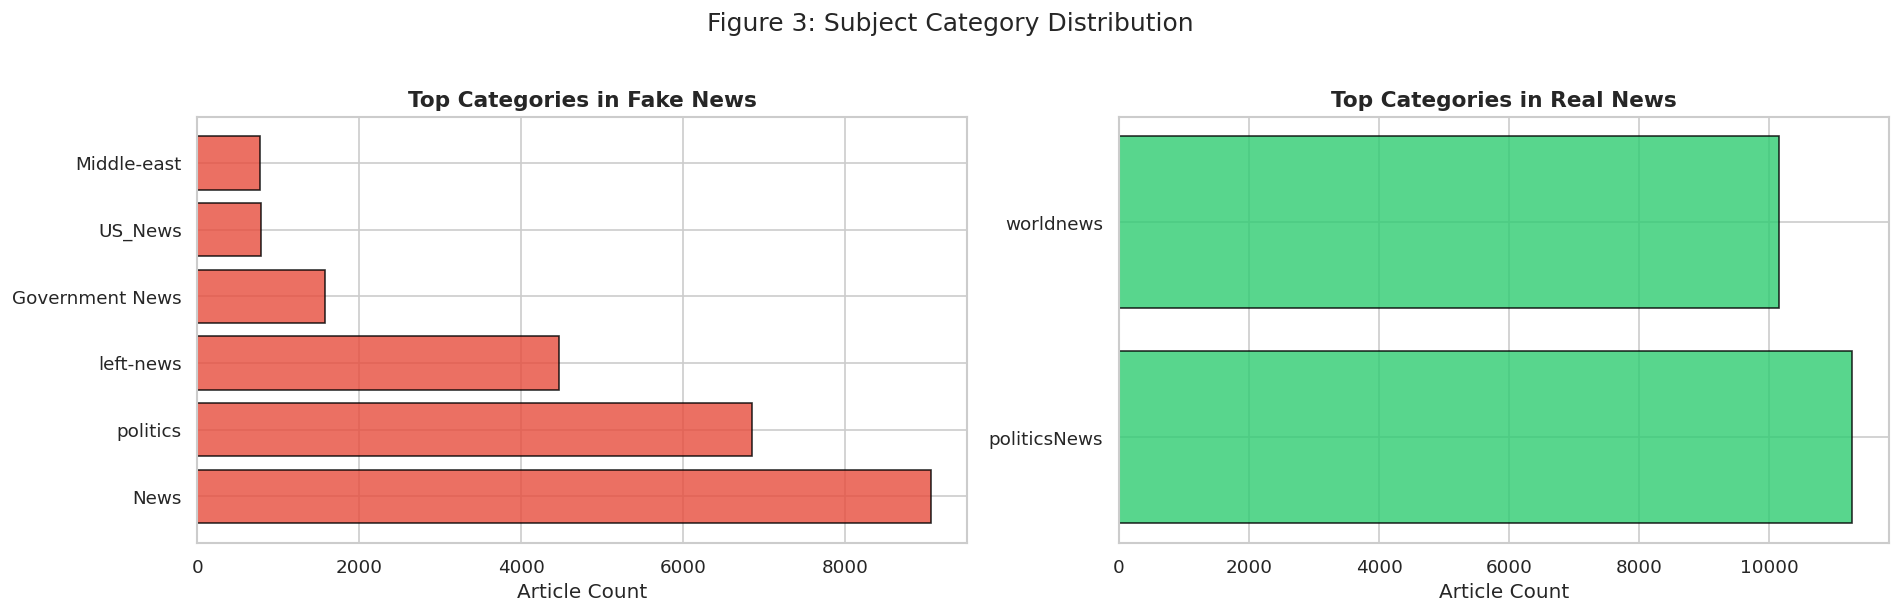

 Figure 3 saved.


In [ ]:
# ── 3.3 Subject / Category Distribution (if column exists) ─────────────────
if 'subject' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, label, color, name in zip(axes, [0, 1], colors, ['Fake', 'Real']):
        counts = df[df['label']==label]['subject'].value_counts().head(8)
        ax.barh(counts.index, counts.values, color=color, alpha=0.8, edgecolor='black')
        ax.set_title(f'Top Categories in {name} News', fontsize=13, fontweight='bold')
        ax.set_xlabel('Article Count')
    plt.suptitle('Figure 3: Subject Category Distribution', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3_subject_distribution.png', bbox_inches='tight')
    plt.show()
    print(' Figure 3 saved.')
else:
    print('  No subject column found — skipping Figure 3.')

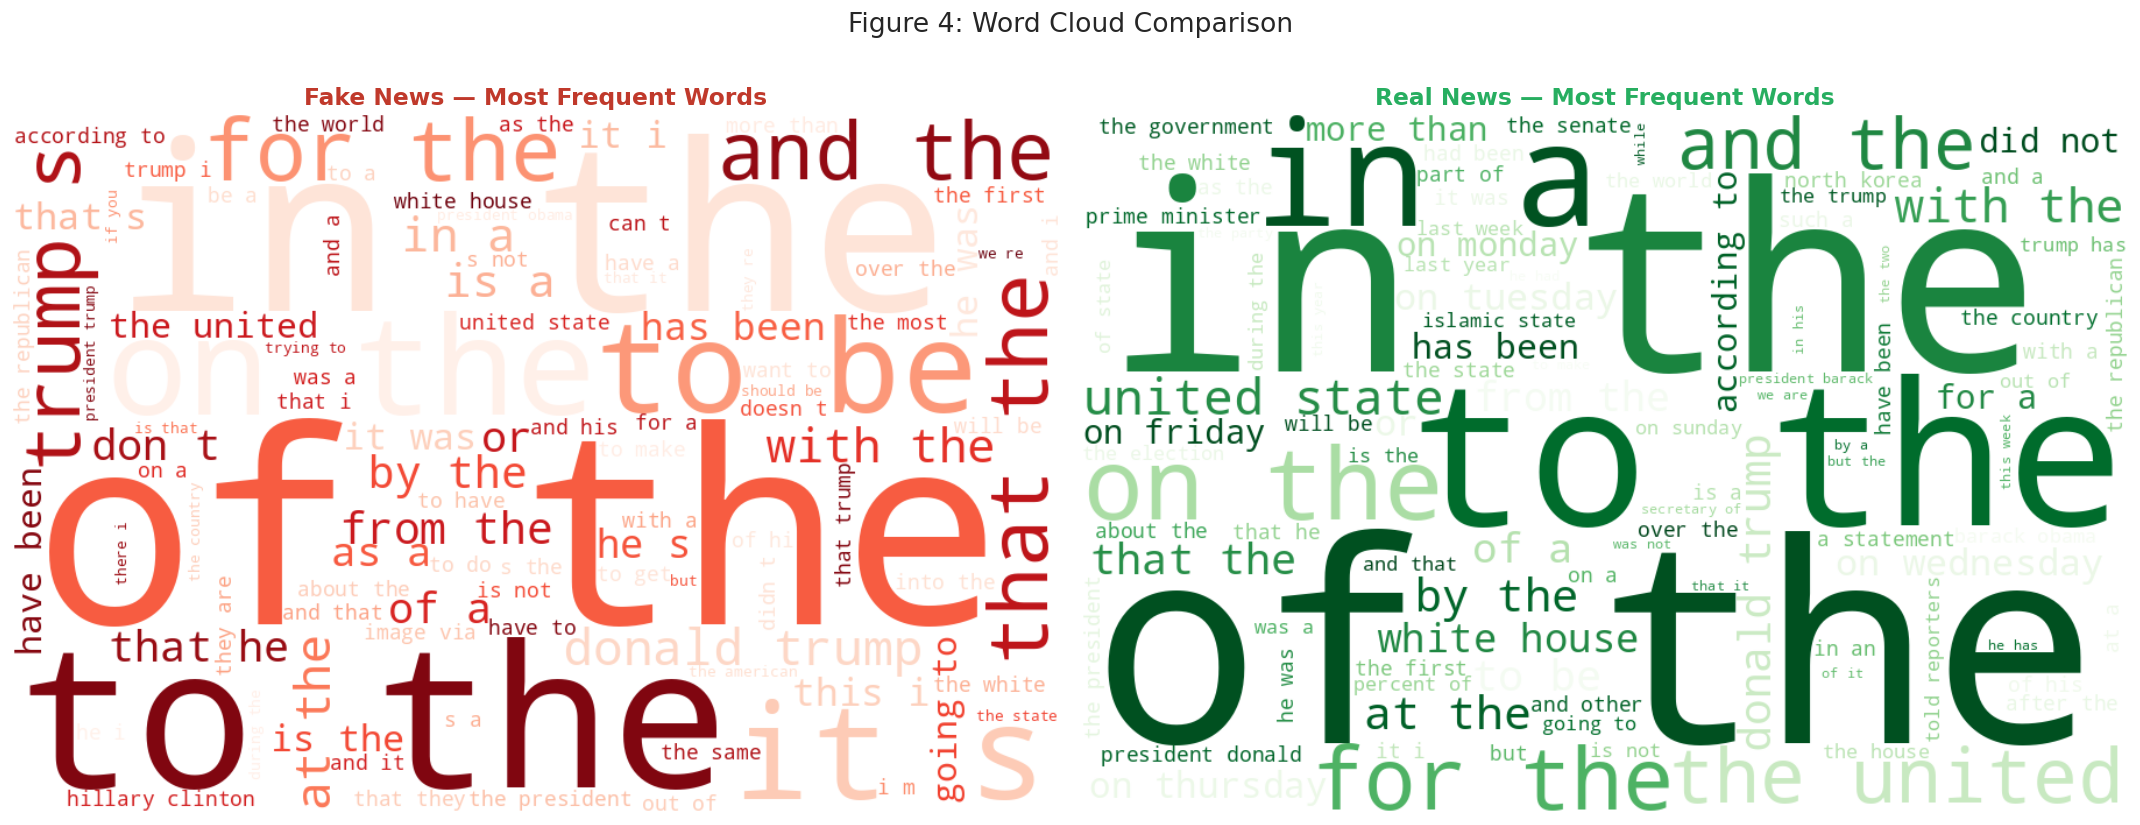

 Figure 4 saved.


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)         # URLs
    text = re.sub(r'[^a-z\s]', '', text)               # non-alpha
    text = re.sub(r'\s+', ' ', text).strip()
    return text

STOPWORDS_EXTRA = {'said', 'would', 'could', 'also', 'one', 'new', 'like',
                   'us', 'reuters', 'ap', 'washington', 'says'}

fake_corpus = ' '.join(df[df['label']==0]['text'].astype(str).apply(clean_text))
real_corpus = ' '.join(df[df['label']==1]['text'].astype(str).apply(clean_text))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_fake = WordCloud(width=900, height=600, background_color='white',
                    colormap='Reds', max_words=100,
                    stopwords=STOPWORDS_EXTRA).generate(fake_corpus)

wc_real = WordCloud(width=900, height=600, background_color='white',
                    colormap='Greens', max_words=100,
                    stopwords=STOPWORDS_EXTRA).generate(real_corpus)

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Fake News — Most Frequent Words', fontsize=14, fontweight='bold', color='#c0392b')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Real News — Most Frequent Words', fontsize=14, fontweight='bold', color='#27ae60')

plt.suptitle('Figure 4: Word Cloud Comparison', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('fig4_wordcloud.png', bbox_inches='tight')
plt.show()
print(' Figure 4 saved.')

In [ ]:
# ── 5.1 Preprocessing & Train-Test Split ───────────────────────────────────
df['clean_text'] = df['text'].astype(str).apply(clean_text)

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                        stop_words='english', sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Training samples : {X_train_tfidf.shape[0]:,}')
print(f'Test samples     : {X_test_tfidf.shape[0]:,}')
print(f'TF-IDF features  : {X_train_tfidf.shape[1]:,}')

Training samples : 35,918
Test samples     : 8,980
TF-IDF features  : 50,000


In [ ]:
# ── 5.2 Train Multiple Models ──────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f' Training {name}...')
    model.fit(X_train_tfidf, y_train)
    preds  = model.predict(X_test_tfidf)
    acc    = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, target_names=['Fake','Real'], output_dict=True)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc, 'report': report}
    print(f'    Accuracy: {acc*100:.2f}%')

print('\n All models trained!')

 Training Logistic Regression...
    Accuracy: 99.23%
 Training Naive Bayes...
    Accuracy: 96.98%
 Training Decision Tree...
    Accuracy: 99.60%
 Training Random Forest...
    Accuracy: 99.73%

 All models trained!


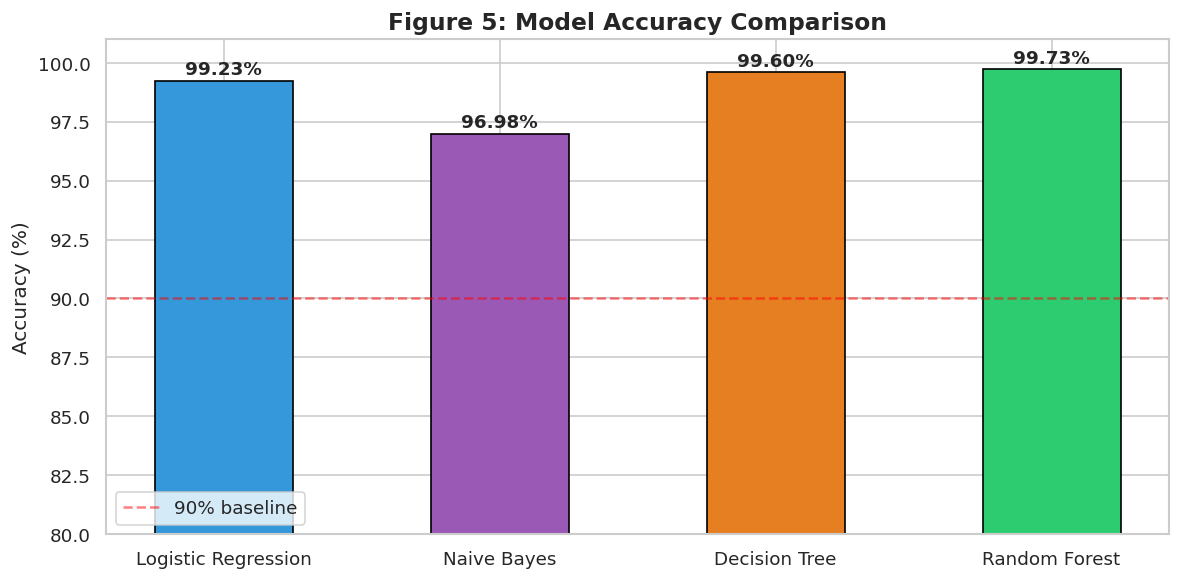

 Figure 5 saved.


In [ ]:
# ── 6.1 Model Accuracy Comparison ─────────────────────────────────────────
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] * 100 for m in model_names]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']
bars = ax.bar(model_names, accuracies, color=bar_colors, edgecolor='black', width=0.5)
ax.set_ylim(80, 101)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Figure 5: Model Accuracy Comparison', fontsize=14, fontweight='bold')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% baseline')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_accuracy_comparison.png', bbox_inches='tight')
plt.show()
print(' Figure 5 saved.')

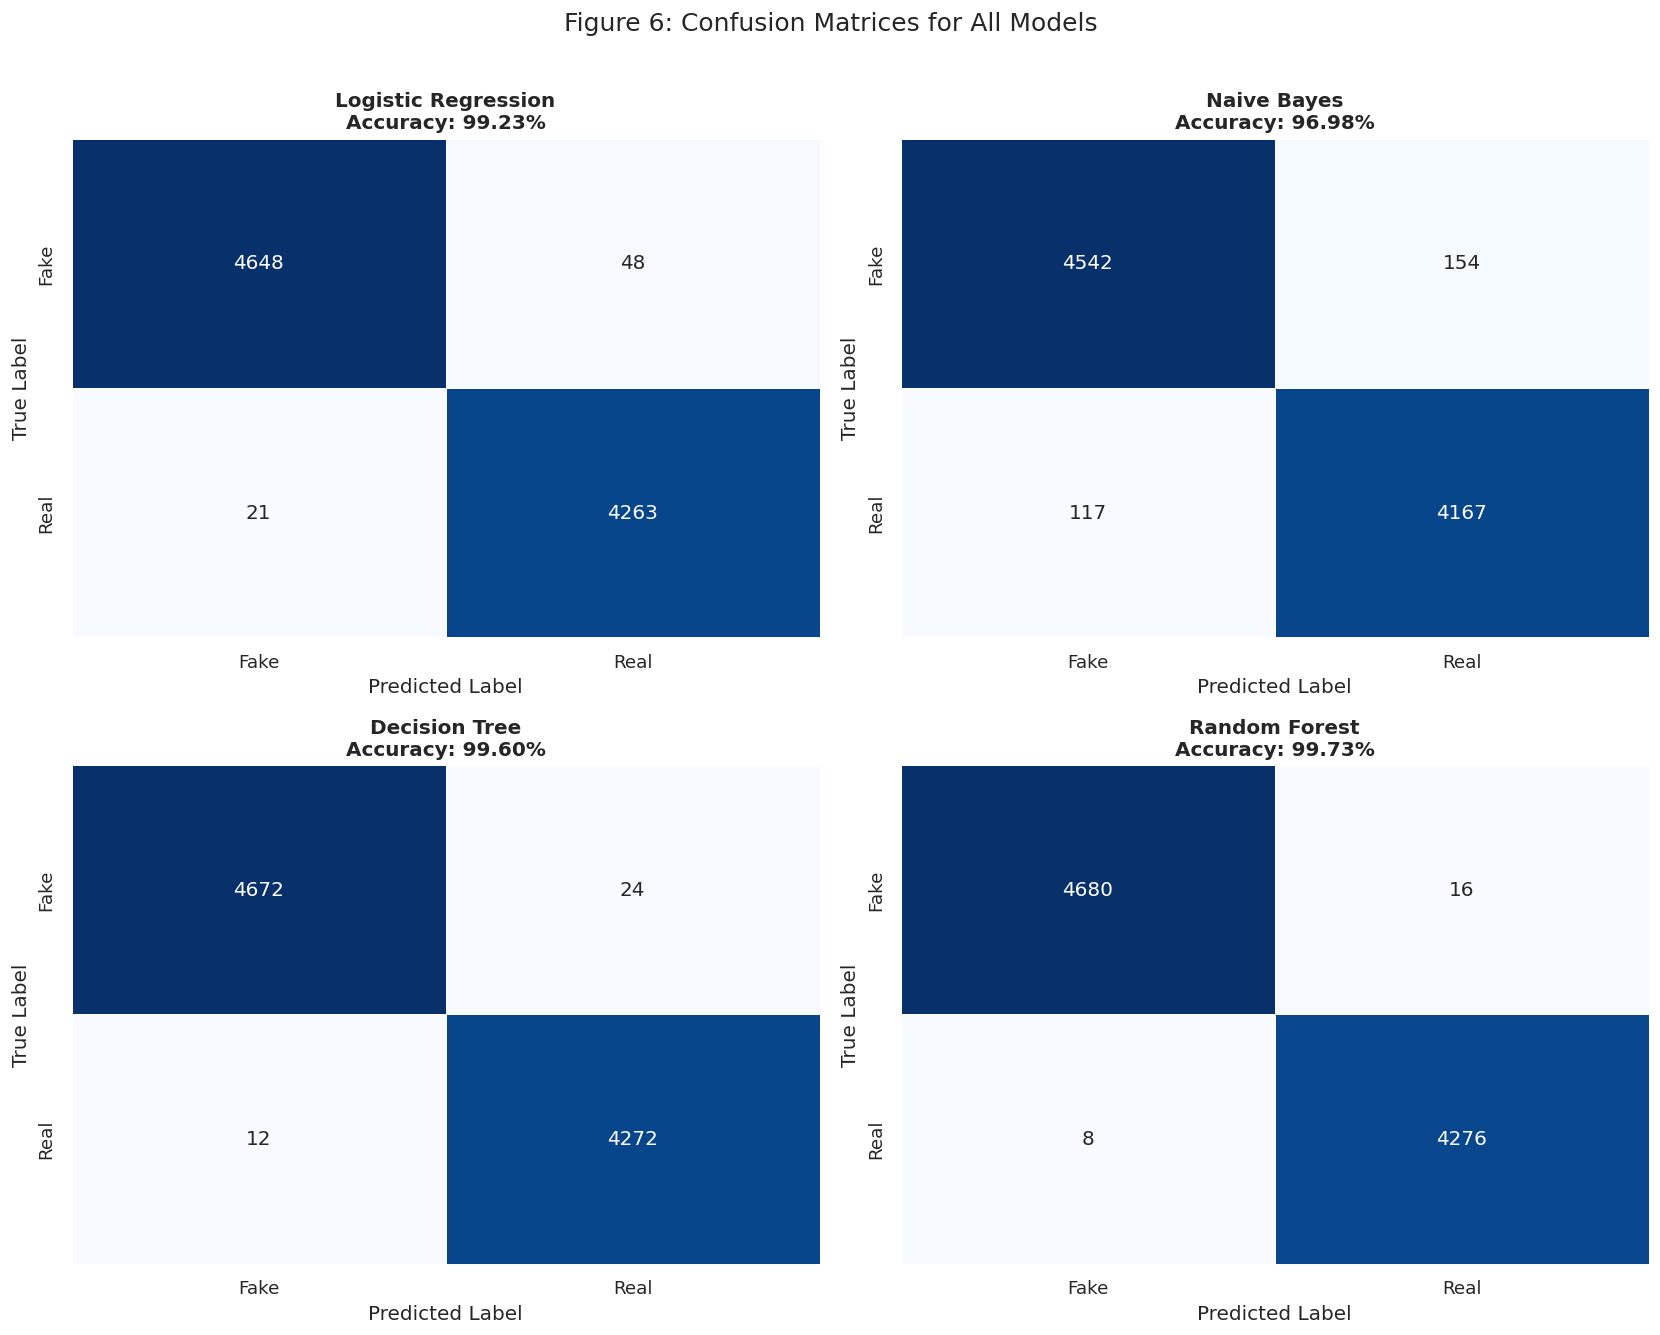

 Figure 6 saved.


In [ ]:
# ── 6.2 Confusion Matrices ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'],
                linewidths=0.5, cbar=False)
    axes[i].set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.2f}%',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.suptitle('Figure 6: Confusion Matrices for All Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', bbox_inches='tight')
plt.show()
print(' Figure 6 saved.')

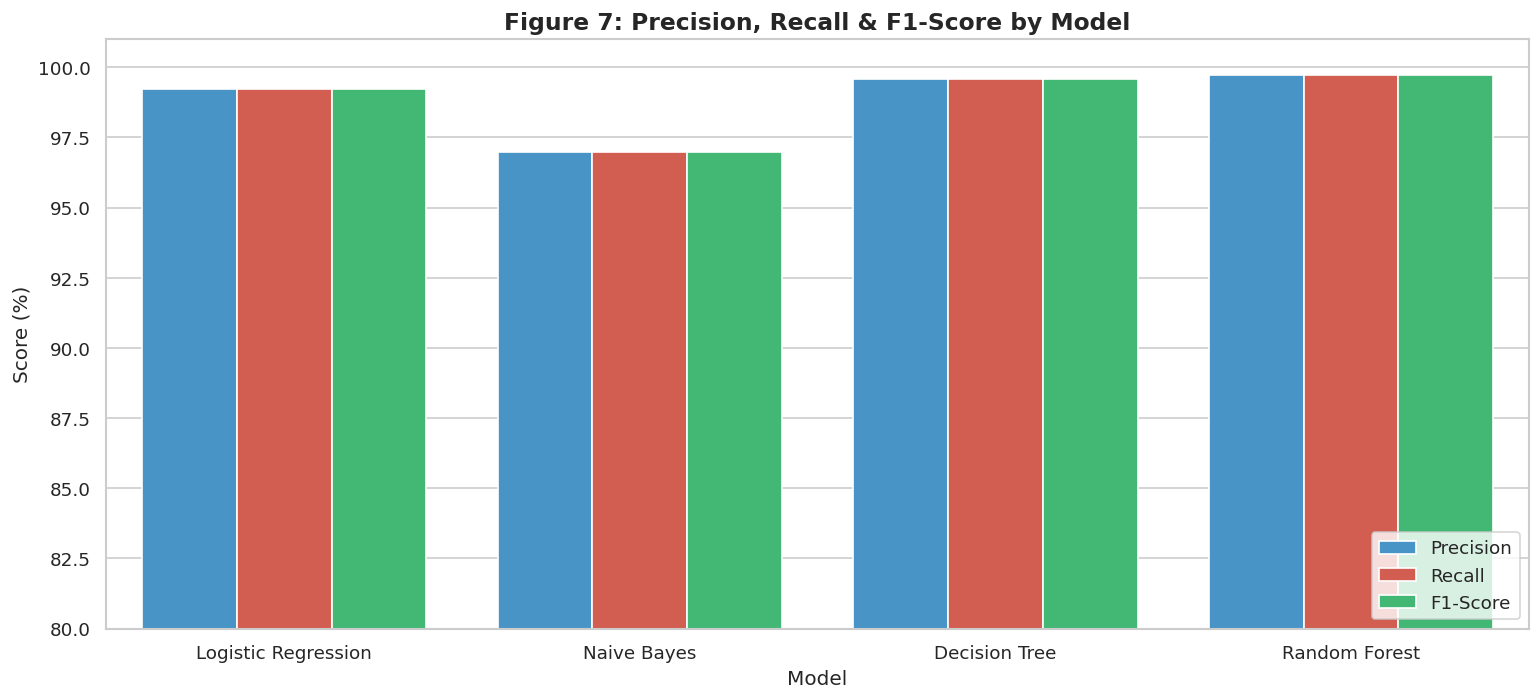

 Figure 7 saved.


In [ ]:
# ── 6.3 Precision / Recall / F1 Grouped Bar Chart ─────────────────────────
metrics_data = {'Model': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for name, res in results.items():
    rpt = res['report']['weighted avg']
    metrics_data['Model'].append(name)
    metrics_data['Precision'].append(rpt['precision'] * 100)
    metrics_data['Recall'].append(rpt['recall'] * 100)
    metrics_data['F1-Score'].append(rpt['f1-score'] * 100)

metrics_df = pd.DataFrame(metrics_data)
metrics_df_melt = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=metrics_df_melt, x='Model', y='Score', hue='Metric',
            palette=['#3498db','#e74c3c','#2ecc71'], ax=ax)
ax.set_ylim(80, 101)
ax.set_ylabel('Score (%)')
ax.set_title('Figure 7: Precision, Recall & F1-Score by Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig7_precision_recall_f1.png', bbox_inches='tight')
plt.show()
print(' Figure 7 saved.')

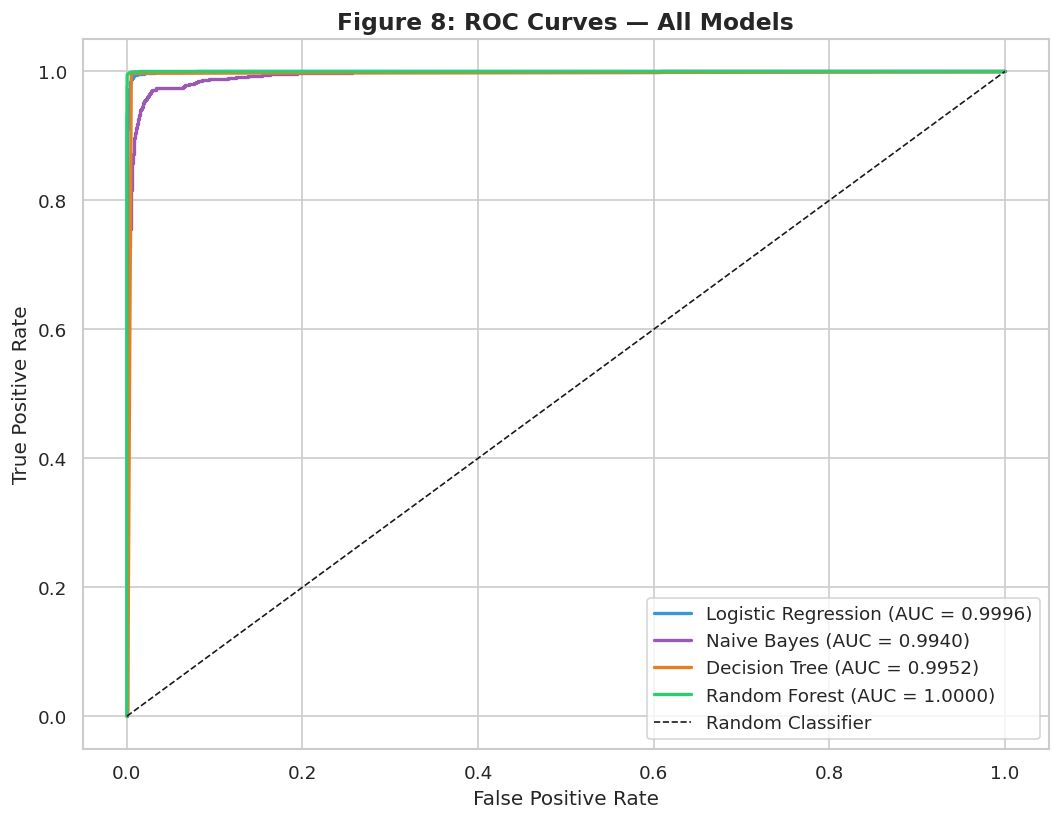

 Figure 8 saved.


In [ ]:
# ── 6.4 ROC Curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db','#9b59b6','#e67e22','#2ecc71']

for (name, res), color in zip(results.items(), colors_roc):
    model = res['model']
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_tfidf)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 8: ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig8_roc_curves.png', bbox_inches='tight')
plt.show()
print(' Figure 8 saved.')

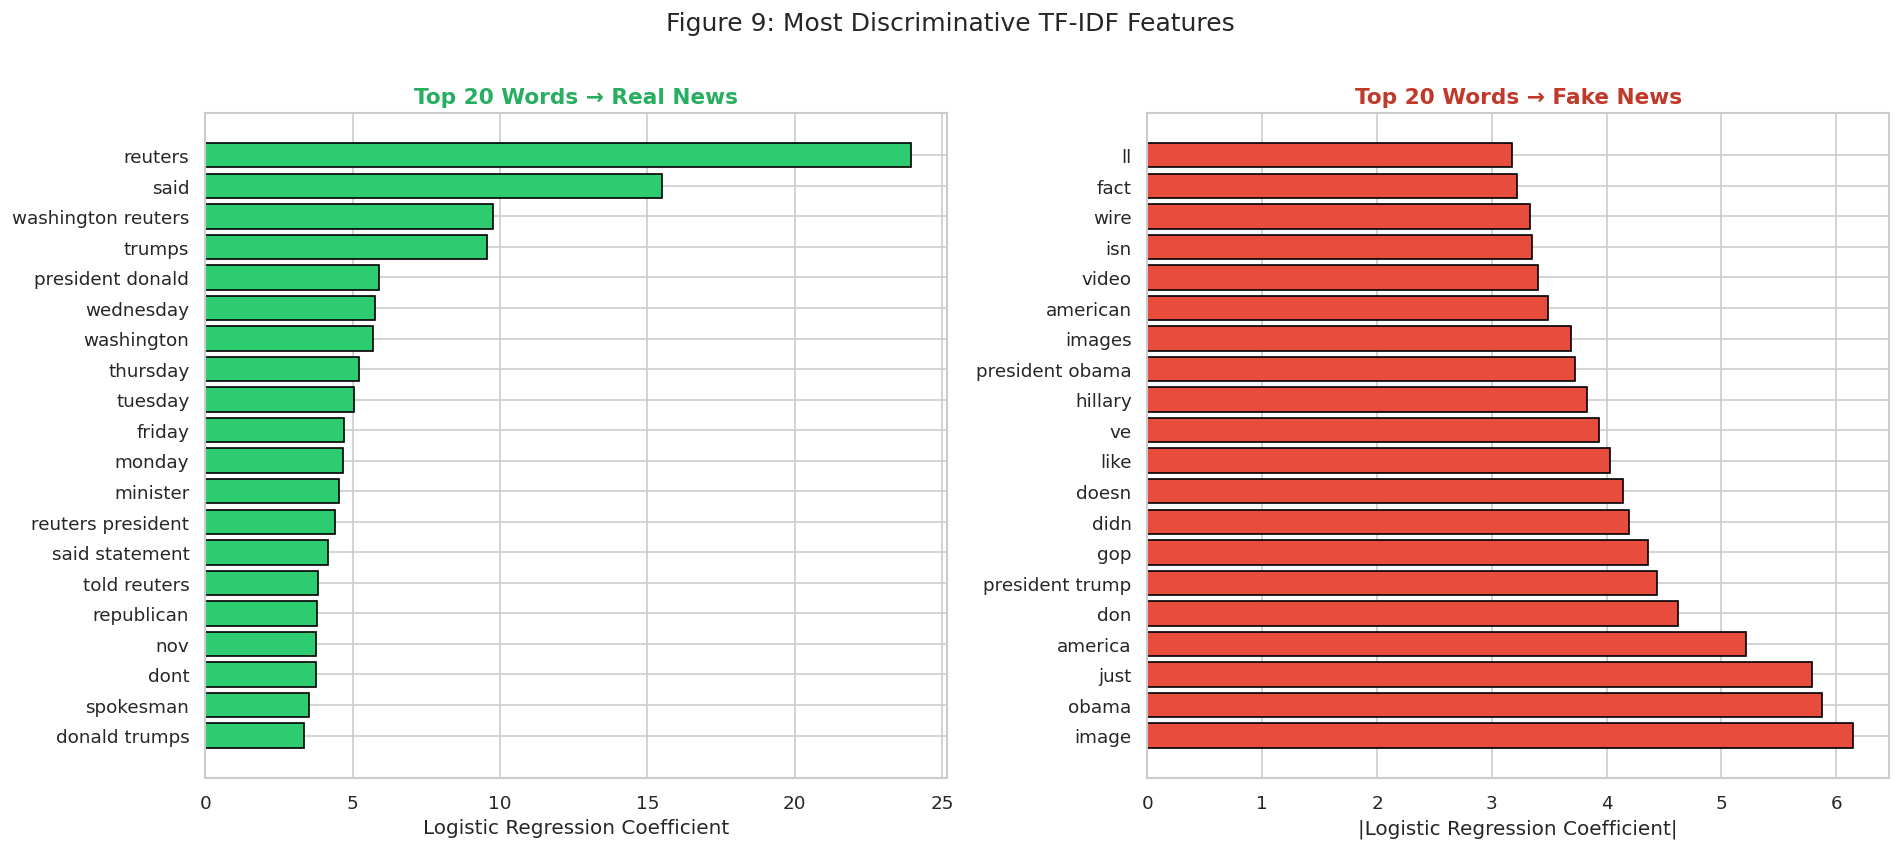

 Figure 9 saved.


In [ ]:
# ── 6.5 Top TF-IDF Features for Logistic Regression ──────────────────────
lr_model = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())
coef = lr_model.coef_[0]

top_real = np.argsort(coef)[-20:]
top_fake = np.argsort(coef)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Real indicators
axes[0].barh(feature_names[top_real], coef[top_real], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 20 Words → Real News', fontsize=13, fontweight='bold', color='#27ae60')
axes[0].set_xlabel('Logistic Regression Coefficient')

# Fake indicators
axes[1].barh(feature_names[top_fake], abs(coef[top_fake]), color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 20 Words → Fake News', fontsize=13, fontweight='bold', color='#c0392b')
axes[1].set_xlabel('|Logistic Regression Coefficient|')

plt.suptitle('Figure 9: Most Discriminative TF-IDF Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig9_top_features.png', bbox_inches='tight')
plt.show()
print(' Figure 9 saved.')

In [ ]:
summary_rows = []
for name, res in results.items():
    rpt = res['report']
    row = {
        'Model'           : name,
        'Accuracy (%)'    : f"{res['accuracy']*100:.2f}",
        'Precision (Fake)': f"{rpt['Fake']['precision']*100:.2f}",
        'Recall (Fake)'   : f"{rpt['Fake']['recall']*100:.2f}",
        'F1 (Fake)'       : f"{rpt['Fake']['f1-score']*100:.2f}",
        'Precision (Real)': f"{rpt['Real']['precision']*100:.2f}",
        'Recall (Real)'   : f"{rpt['Real']['recall']*100:.2f}",
        'F1 (Real)'       : f"{rpt['Real']['f1-score']*100:.2f}",
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print('\n Model Performance Summary Table:')
print('=' * 90)
print(summary_df.to_string(index=False))
print('=' * 90)
summary_df.to_csv('model_summary.csv', index=False)
print('\n Summary saved to model_summary.csv')


 Model Performance Summary Table:
              Model Accuracy (%) Precision (Fake) Recall (Fake) F1 (Fake) Precision (Real) Recall (Real) F1 (Real)
Logistic Regression        99.23            99.55         98.98     99.26            98.89         99.51     99.20
        Naive Bayes        96.98            97.49         96.72     97.10            96.44         97.27     96.85
      Decision Tree        99.60            99.74         99.49     99.62            99.44         99.72     99.58
      Random Forest        99.73            99.83         99.66     99.74            99.63         99.81     99.72

 Summary saved to model_summary.csv


In [ ]:
import urllib.request
import urllib.parse
import xml.etree.ElementTree as ET
import re

TRUSTED_SOURCES = [
    "Times of India", "TV9", "Deccan Chronicle", "Deccan Herald",
    "NDTV", "The Hindu", "India Today", "Hindustan Times", "News18",
    "The Indian Express", "Firstpost", "Livemint", "Business Standard",
    "Alt News", "Boom Live", "Factly"
]
DEBUNK_TERMS = ['hoax','fake news','debunk','fact check','unproven',
                'conspiracy','satire','misleading','false']

def verify_news_live(text):
    clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    query = urllib.parse.quote(clean_text[:100])
    url = f"https://news.google.com/rss/search?q={query}&hl=en-IN&gl=IN&ceid=IN:en"
    try:
        req  = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        resp = urllib.request.urlopen(req)
        root = ET.fromstring(resp.read())
        items = root.findall('./channel/item')
        if not items:
            return {'prediction':'Unverified','confidence':0,'reason':'No coverage found.','sources':[]}
        debunk_hits = trusted_reports = 0
        top_sources = []
        for item in items[:5]:
            title     = item.find('title').text or ''
            link      = item.find('link').text
            src_tag   = item.find('source')
            publisher = src_tag.text if src_tag is not None else 'Unknown'
            top_sources.append({'title': f'{publisher}: {title}', 'url': link})
            if any(t in title.lower() for t in DEBUNK_TERMS): debunk_hits += 1
            if any(ts.lower() in publisher.lower() for ts in TRUSTED_SOURCES): trusted_reports += 1
        if debunk_hits > 0:
            return {'prediction':'Fake News','confidence':min(100,70+debunk_hits*10),
                    'reason':'Flagged by fact-checkers.','sources':top_sources}
        elif trusted_reports > 0:
            return {'prediction':'Real News','confidence':min(100,60+trusted_reports*10),
                    'reason':f'Reported by {trusted_reports} trusted network(s).','sources':top_sources}
        else:
            return {'prediction':'Unverified','confidence':50,
                    'reason':'In the news, but not by primary trusted publishers.','sources':top_sources}
    except Exception as e:
        return {'error': str(e)}

# --- Test with sample headlines ---
TEST_CLAIMS = [
    "India launches new satellite into orbit successfully",
    "Drinking bleach cures all diseases government confirms",
    "Budget 2025 India announces income tax changes",
]

print(' Live Google News Verification Results\n' + '='*60)
live_rows = []
for claim in TEST_CLAIMS:
    result = verify_news_live(claim)
    print(f'\nClaim     : {claim[:60]}...')
    if 'error' not in result:
        print(f'Verdict   : {result["prediction"]}')
        print(f'Confidence: {result["confidence"]}%')
        print(f'Reason    : {result["reason"]}')
        live_rows.append({'Claim': claim[:60], 'Verdict': result['prediction'],
                          'Confidence': result['confidence']})
    else:
        print(f'Error: {result["error"]}')

 Live Google News Verification Results

Claim     : India launches new satellite into orbit successfully...
Verdict   : Real News
Confidence: 70%
Reason    : Reported by 1 trusted network(s).

Claim     : Drinking bleach cures all diseases government confirms...
Verdict   : Unverified
Confidence: 50%
Reason    : In the news, but not by primary trusted publishers.

Claim     : Budget 2025 India announces income tax changes...
Verdict   : Real News
Confidence: 70%
Reason    : Reported by 1 trusted network(s).


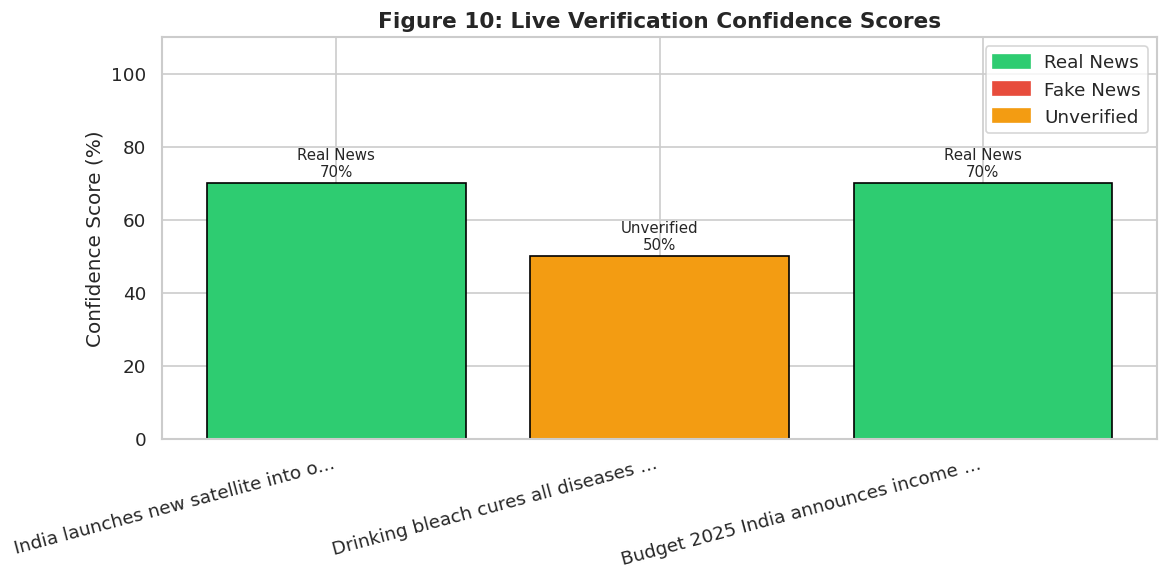

 Figure 10 saved.


In [ ]:
# ── Live Results Bar Chart ─────────────────────────────────────────────────
if live_rows:
    live_df = pd.DataFrame(live_rows)
    palette = {'Real News':'#2ecc71', 'Fake News':'#e74c3c', 'Unverified':'#f39c12'}
    bar_colors_live = [palette.get(v, '#95a5a6') for v in live_df['Verdict']]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(range(len(live_df)), live_df['Confidence'], color=bar_colors_live, edgecolor='black')
    ax.set_xticks(range(len(live_df)))
    ax.set_xticklabels([c[:35]+'...' for c in live_df['Claim']], rotation=15, ha='right')
    ax.set_ylabel('Confidence Score (%)')
    ax.set_ylim(0, 110)
    ax.set_title('Figure 10: Live Verification Confidence Scores', fontsize=13, fontweight='bold')
    patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
    ax.legend(handles=patches)
    for bar, row in zip(bars, live_df.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1,
                f'{row.Verdict}\n{row.Confidence}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig10_live_results.png', bbox_inches='tight')
    plt.show()
    print(' Figure 10 saved.')

In [ ]:
import zipfile, os
from google.colab import files

fig_files = [f for f in os.listdir('.') if f.endswith('.png') or f.endswith('.csv')]

with zipfile.ZipFile('term_paper_figures.zip', 'w') as zf:
    for f in fig_files:
        zf.write(f)
        print(f'   Added: {f}')

print(f'\n Downloading term_paper_figures.zip ({len(fig_files)} files)...')
files.download('term_paper_figures.zip')

   Added: fig3_subject_distribution.png
   Added: fig1_class_distribution.png
   Added: model_summary.csv
   Added: fig9_top_features.png
   Added: fig5_accuracy_comparison.png
   Added: fig2_article_length.png
   Added: True.csv
   Added: fig8_roc_curves.png
   Added: fig6_confusion_matrices.png
   Added: fig10_live_results.png
   Added: fig4_wordcloud.png
   Added: fig7_precision_recall_f1.png
   Added: Fake.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
##  Summary

| Section | What Was Done |
|---------|---------------|
| EDA | Class distribution, article length analysis, subject categories |
| Word Clouds | Visual comparison of frequent terms in fake vs real news |
| ML Models | Logistic Regression, Naive Bayes, Decision Tree, Random Forest |
| Metrics | Accuracy, Precision, Recall, F1-Score, ROC-AUC for all models |
| Feature Analysis | Top discriminative TF-IDF features (Logistic Regression) |
| Live System | Real-time Google News RSS verification demo |

**All figures are downloaded as a ZIP for inclusion in your term paper.**